## Preprocessing


In [ ]:
import pandas as pd
import numpy as np

# =============================================================================
# MODULO DATA ENGINEERING: PREPARAZIONE DATASET CSP - MUMBAI CON AREE
# =============================================================================
print("=" * 70)
print(" 🚀 DATA ENGINEERING: GENERAZIONE DATASET CSP (CON AREE GEOGRAFICHE)")
print("=" * 70)

# ─────────────────────────────────────────────
# 1. CARICAMENTO E FILTRO GEOGRAFICO
# ─────────────────────────────────────────────
try:
    df = pd.read_csv("../Preprocessing/amazon_delivery_final.csv")
    print(f"\n[1] Dataset originale caricato: {len(df)} righe.")
except FileNotFoundError:
    raise FileNotFoundError("Il file dataset non è stato trovato. Verifica il percorso.")

# Filtro geografico stretto (Bounding Box per Mumbai)
mumbai_mask = (
    (df["Store_Latitude"].between(18.9, 19.3)) &
    (df["Store_Longitude"].between(72.7, 73.0))
)
df_mumbai = df[mumbai_mask].copy().reset_index(drop=True)
print(f"    Righe filtrate nell'area di Mumbai: {len(df_mumbai)}")

if len(df_mumbai) < 60:
    raise ValueError("Dati insufficienti a Mumbai per estrarre 30 ordini e gli agenti necessari.")

# ─────────────────────────────────────────────
# 2. TRASFORMAZIONE DATI (KNOWLEDGE NORMALIZATION)
# ─────────────────────────────────────────────
print("\n[2] Normalizzazione della Conoscenza: De-standardizzazione Rating...")

z_min = df_mumbai["Agent_Rating"].min()
z_max = df_mumbai["Agent_Rating"].max()

# Applicazione della formula: Rating = ((Z - Zmin) / (Zmax - Zmin)) * 4 + 1
df_mumbai["Agent_Rating"] = ((df_mumbai["Agent_Rating"] - z_min) / (z_max - z_min)) * 4.0 + 1.0
df_mumbai["Agent_Rating"] = df_mumbai["Agent_Rating"].round(1)

print(f"    Rating scalati nel range [1.0 - 5.0]. Media attuale: {df_mumbai['Agent_Rating'].mean():.2f}")

# ─────────────────────────────────────────────
# 3. SELEZIONE VARIABILI CSP (30 ORDINI)
# ─────────────────────────────────────────────
print("\n[3] Estrazione delle Variabili (Ordini) con info Area...")
np.random.seed(42)

# Pool separati per garantire i vincoli minimi
home_pool = df_mumbai[df_mumbai["Category_Home"] == 1]
elec_pool = df_mumbai[df_mumbai["Category_Electronics"] == 1]

# Estrazione vincolata
sample_home = home_pool.sample(n=min(6, len(home_pool)), random_state=42)
sample_elec = elec_pool.drop(index=sample_home.index, errors="ignore")
sample_elec = sample_elec.sample(n=min(6, len(sample_elec)), random_state=42)

# Completamento fino a 30 ordini
used_order_indices = set(sample_home.index) | set(sample_elec.index)
remaining_orders = df_mumbai.drop(index=list(used_order_indices))
needed = 30 - len(sample_home) - len(sample_elec)
sample_other = remaining_orders.sample(n=needed, random_state=42)

# Creazione blocco Ordini
orders = pd.concat([sample_home, sample_elec, sample_other]).reset_index(drop=True)
orders["Record_Type"] = "ORDER"
orders["Agent_ID"] = np.nan

if "Order_ID" not in orders.columns:
    orders["Order_ID"] = [f"ORD_{i+1:03d}" for i in range(len(orders))]

used_order_indices.update(sample_other.index)
print(f"    Ordini estratti: {len(orders)} (di cui {len(sample_home)} Home, {len(sample_elec)} Electronics)")

# ─────────────────────────────────────────────
# 4. SELEZIONE DOMINIO CSP (12 AGENTI) CON INFO AREA
# ─────────────────────────────────────────────
print("\n[4] Configurazione del Dominio (Agenti) con info Area...")

# Pool agenti (escludendo gli ordini)
agent_pool = df_mumbai.drop(index=list(used_order_indices)).copy()

# Requisiti: 6 Van e 6 Moto
van_agents = agent_pool[agent_pool["Vehicle_van"] == 1].sample(n=6, random_state=42)
moto_pool  = agent_pool.drop(index=van_agents.index, errors="ignore")
moto_agents = moto_pool[moto_pool["Vehicle_motorcycle"] == 1].sample(n=6, random_state=42)

agents = pd.concat([van_agents, moto_agents])

# Assicuriamo che almeno 5 abbiano rating > 3.8
high_rating_count = (agents["Agent_Rating"] > 3.8).sum()
if high_rating_count < 5:
    needed_high = 5 - high_rating_count
    replacements = agent_pool.drop(index=agents.index, errors="ignore")
    replacements = replacements[replacements["Agent_Rating"] > 3.8].head(needed_high)
    
    if not replacements.empty:
        agents = agents.sort_values("Agent_Rating").iloc[len(replacements):]
        agents = pd.concat([agents, replacements])

agents = agents.reset_index(drop=True)
agents["Agent_ID"] = [f"Agente_{i+1}" for i in range(len(agents))]
agents["Record_Type"] = "AGENT"
agents["Order_ID"] = np.nan

print(f"    Agenti estratti: {len(agents)} (Van: {agents['Vehicle_van'].sum()}, Moto: {agents['Vehicle_motorcycle'].sum()})")
print(f"    Agenti con Rating > 3.8: {(agents['Agent_Rating'] > 3.8).sum()}")

# ─────────────────────────────────────────────
# 5. ESPORTAZIONE E PULIZIA
# ─────────────────────────────────────────────
print("\n[5] Pulizia colonne ed Esportazione...")

# Definizione e ordine delle colonne finali (Schema Target ESPANSO CON AREE)
COLUMNS = [
    "Order_ID",
    "Agent_ID",
    "Record_Type",
    "Agent_Rating",
    "Vehicle_motorcycle",
    "Vehicle_van",
    "Category_Home",
    "Category_Electronics",
    "Area_Urban",
    "Area_Metropolitian",
    "Area_Semi-Urban"
]

# Concateniamo con gli Agenti in testa
final_df = pd.concat([agents, orders], ignore_index=True)

# Forziamo eventuali colonne mancanti a NaN e applichiamo lo schema
for col in COLUMNS:
    if col not in final_df.columns:
        final_df[col] = np.nan
final_df = final_df[COLUMNS]

# Pulizia logica: per gli ordini rimuoviamo le info esclusive degli agenti, 
# TRANNE le info di Area, che servono a ENTRAMBI!
final_df.loc[final_df["Record_Type"] == "ORDER", ["Vehicle_motorcycle", "Vehicle_van", "Agent_Rating"]] = np.nan

# Pulizia logica: per gli agenti rimuoviamo le info esclusive degli ordini
final_df.loc[final_df["Record_Type"] == "AGENT", ["Category_Home", "Category_Electronics"]] = np.nan

output_path = "csp_mumbai_espanso.csv"
final_df.to_csv(output_path, index=False)
print(f"    ✅ Dataset salvato con successo in: {output_path}")

# ─────────────────────────────────────────────
# 6. VERIFICA FINALE (OUTPUT RICHIESTO)
# ─────────────────────────────────────────────
print("\n" + "=" * 70)
print(" 📊 VERIFICA COLONNE AREA")
print("=" * 70)
print("Prime 3 righe (AGENTI):")
print(final_df[final_df["Record_Type"] == "AGENT"][["Agent_ID", "Area_Urban", "Area_Metropolitian", "Area_Semi-Urban"]].head(3).to_string(index=False))

print("\nPrime 3 righe (ORDINI):")
print(final_df[final_df["Record_Type"] == "ORDER"][["Order_ID", "Area_Urban", "Area_Metropolitian", "Area_Semi-Urban"]].head(3).to_string(index=False))
print("=" * 70)

## Backtracking

In [8]:
import pandas as pd
import random
import time

# =============================================================================
# MODELLAZIONE CSP AVANZATA - BACKTRACKING CON COERENZA GEOGRAFICA
# Capitolo 3 (Pinto) - Ricerca con vincoli di stato e Search Bias
# =============================================================================

print("=" * 80)
print(" 🧠 AI SOLVER: CSP BACKTRACKING AVANZATO (Aree & Capacità Specializzate)")
print("=" * 80)

# ─────────────────────────────────────────────
# 1. CARICAMENTO E PREPARAZIONE DATI
# ─────────────────────────────────────────────
df = pd.read_csv("csp_mumbai_espanso.csv")

def determina_area(row):
    """Estrae l'etichetta dell'area dalle colonne one-hot"""
    if row.get("Area_Urban") == 1.0: return "Urban"
    if row.get("Area_Metropolitian") == 1.0: return "Metropolitan"
    if row.get("Area_Semi-Urban") == 1.0: return "Semi-Urban"
    return "Unknown"

# Estrazione Variabili (Ordini)
df_orders = df[df["Record_Type"] == "ORDER"].copy()
orders = []
for _, row in df_orders.iterrows():
    orders.append({
        "Order_ID": row["Order_ID"],
        "Is_Home": row["Category_Home"] == 1.0,
        "Is_Electronics": row["Category_Electronics"] == 1.0,
        "Area": determina_area(row)
    })

# Estrazione Dominio (Agenti)
df_agents = df[df["Record_Type"] == "AGENT"].copy()
agents = {}
for _, row in df_agents.iterrows():
    is_van = row["Vehicle_van"] == 1.0
    agents[row["Agent_ID"]] = {
        "Rating": row["Agent_Rating"],
        "Is_Van": is_van,
        # Capacità totali e specializzate (Home)
        "Max_Total": 5 if is_van else 2,
        "Max_Home": 3 if is_van else 1
    }

print(f"[1] Variabili (X) caricate: {len(orders)} Ordini")
print(f"[1] Dominio (D) caricato: {len(agents)} Agenti")

# ─────────────────────────────────────────────
# 2. DEFINIZIONE DEI VINCOLI (HARD CONSTRAINTS)
# ─────────────────────────────────────────────
def is_valid_assignment(order, agent_id, agent_data, trackers):
    """
    Verifica se l'assegnazione parziale rispetta TUTTI i nuovi vincoli.
    """
    loads_total = trackers["loads_total"]
    loads_home = trackers["loads_home"]
    agent_areas = trackers["agent_areas"]
    
    # C1a - Capacità Globale
    if loads_total[agent_id] >= agent_data["Max_Total"]:
        return False, "Capacità totale esaurita"
        
    # C1b - Capacità Specializzata (Home)
    if order["Is_Home"] and loads_home[agent_id] >= agent_data["Max_Home"]:
        return False, "Capacità pacchi Home (pesanti) esaurita"
    
    # C2 - Coerenza Area Geografica
    current_agent_area = agent_areas[agent_id]
    if current_agent_area is not None and current_agent_area != order["Area"]:
        return False, f"Incoerenza Area (Agente è in {current_agent_area}, Ordine è in {order['Area']})"
    
    # C3 - Requisito Qualità (Electronics -> Rating > 3.8)
    if order["Is_Electronics"] and agent_data["Rating"] <= 3.8:
        return False, "Rating insufficiente per Electronics"
        
    return True, "OK"

# ─────────────────────────────────────────────
# 3. MOTORE DI RICERCA BACKTRACKING (DFS)
# ─────────────────────────────────────────────
stats = {"nodes_visited": 0, "backtracks": 0}

def backtrack_solve(unassigned_orders, assignment, trackers):
    # Caso base: tutti gli ordini assegnati
    if not unassigned_orders:
        return assignment
    
    stats["nodes_visited"] += 1
    current_order = unassigned_orders[0]
    order_id = current_order["Order_ID"]
    
    # OTTIMIZZAZIONE (Search Bias): Mescoliamo il dominio degli agenti
    # Evita che il motore tenti sempre di riempire l'Agente_1 prima di passare all'Agente_2
    agent_ids = list(agents.keys())
    random.shuffle(agent_ids)
    
    for agent_id in agent_ids:
        agent_data = agents[agent_id]
        
        # Verifica Vincoli
        is_valid, _ = is_valid_assignment(current_order, agent_id, agent_data, trackers)
        
        if is_valid:
            # --- ASSEGNAZIONE (Forward) ---
            assignment[order_id] = agent_id
            trackers["loads_total"][agent_id] += 1
            if current_order["Is_Home"]:
                trackers["loads_home"][agent_id] += 1
                
            # Gestione stato Area (se è il suo primo pacco, blocchiamo l'area)
            previous_area = trackers["agent_areas"][agent_id]
            if previous_area is None:
                trackers["agent_areas"][agent_id] = current_order["Area"]
            
            # --- RICORSIONE (Scende nel ramo DFS) ---
            result = backtrack_solve(unassigned_orders[1:], assignment, trackers)
            if result is not None:
                return result # Soluzione trovata!
            
            # --- BACKTRACKING (Passo indietro) ---
            stats["backtracks"] += 1
            if stats["backtracks"] % 2000 == 0:  # Stampa un campione di backtrack
                print(f"  [🔙 Backtrack #{stats['backtracks']}] Ramo cieco individuato. Rollback...")
            
            del assignment[order_id]
            trackers["loads_total"][agent_id] -= 1
            if current_order["Is_Home"]:
                trackers["loads_home"][agent_id] -= 1
                
            # Se rimuovendo questo ordine l'agente torna vuoto, liberiamo la sua Area
            if trackers["loads_total"][agent_id] == 0:
                trackers["agent_areas"][agent_id] = None

    return None # Nessuna soluzione in questo ramo

# ─────────────────────────────────────────────
# 4. ESECUZIONE
# ─────────────────────────────────────────────
print("\n[2] Avvio ricerca DFS Backtracking (con Shuffling del Dominio)...")
start_time = time.time()

# Strutture dati per tracciare lo stato dei vincoli durante la ricerca
state_trackers = {
    "loads_total": {a_id: 0 for a_id in agents.keys()},
    "loads_home":  {a_id: 0 for a_id in agents.keys()},
    "agent_areas": {a_id: None for a_id in agents.keys()} # Nessuna area iniziale
}

# Fissiamo un seed per la riproducibilità, ma puoi toglierlo per risultati sempre diversi
random.seed(42) 

final_assignment = backtrack_solve(orders, {}, state_trackers)

exec_time = time.time() - start_time

# ─────────────────────────────────────────────
# 5. OUTPUT FINALE E REPORT
# ─────────────────────────────────────────────
print("\n" + "=" * 80)
if final_assignment:
    print(f" ✅ SOLUZIONE TROVATA in {exec_time:.4f} secondi!")
    print(f"    Nodi esplorati: {stats['nodes_visited']} | Backtracks effettuati: {stats['backtracks']}")
    print("=" * 80)
    
    # Costruzione lista riepilogativa ordini
    res_list = []
    for o in orders:
        o_id = o["Order_ID"]
        a_id = final_assignment[o_id]
        
        cat = "Standard"
        if o["Is_Home"]: cat = "Home (Pesante)"
        if o["Is_Electronics"]: cat = "Electronics"
            
        res_list.append({
            "Order_ID": o_id,
            "Agente": a_id,
            "Area Ordine": o["Area"],
            "Categoria": cat
        })
        
    df_results = pd.DataFrame(res_list)
    # Ordiniamo prima per agente e poi per categoria per averli in ordine logico
    df_results = df_results.sort_values(by=["Agente", "Categoria"])
    
    print("\n📋 DETTAGLIO ASSEGNAZIONI (Raggruppate per Agente):")
    print("-" * 80)
    
    # Raggruppamento per Agente per una visualizzazione ad albero
    grouped = df_results.groupby("Agente")
    for agente, group in grouped:
        area_agente = state_trackers["agent_areas"][agente]
        mezzo_icona = "🚐 Van " if agents[agente]["Is_Van"] else "🏍️ Moto"
        
        print(f"👤 {agente} | {mezzo_icona} | 📍 Area Operativa: {area_agente}")
        
        for _, row in group.iterrows():
            # Assegnazione di un'icona basata sulla categoria del pacco
            icona_cat = "📦"
            if "Home" in row["Categoria"]: icona_cat = "🛋️"
            if "Electronics" in row["Categoria"]: icona_cat = "💻"
            
            print(f"   ├─ {icona_cat} Ordine: {row['Order_ID']} | Categoria: {row['Categoria']}")
        print("   └─" + "─" * 45)

    print("\n📊 RIEPILOGO CARICO AGENTI E CAPACITÀ:")
    print("-" * 80)
    for a_id, a_data in agents.items():
        load_tot = state_trackers["loads_total"][a_id]
        load_home = state_trackers["loads_home"][a_id]
        area = state_trackers["agent_areas"][a_id]
        
        mezzo = "🚐 Van " if a_data["Is_Van"] else "🏍️ Moto"
        max_tot = a_data["Max_Total"]
        max_home = a_data["Max_Home"]
        
        area_str = area if area else "Nessuna Area"
        
        # Creazione delle barre di caricamento visive
        bar_tot = "█" * load_tot + "░" * (max_tot - load_tot)
        bar_home = "█" * load_home + "░" * (max_home - load_home)
        
        if load_tot > 0:
            print(f" {mezzo} {a_id} (Rating: {a_data['Rating']:.1f}) -> 📍 {area_str}")
            print(f"      Carico Totale : [{bar_tot}] {load_tot}/{max_tot} pacchi")
            if a_data["Is_Van"] or load_home > 0: # Mostra la capacità Home se pertinente
                print(f"      Carico Home   : [{bar_home}] {load_home}/{max_home} pacchi pesanti")
        else:
            print(f" {mezzo} {a_id} -> 💤 INATTIVO (Nessun ordine assegnato)")
        print()

else:
    print(f" ❌ NESSUNA SOLUZIONE. Problema sovra-vincolato.")
    print(f"    Nodi esplorati: {stats['nodes_visited']} | Backtracks falliti: {stats['backtracks']}")
    print("    Suggerimento: Controlla che le capacità e i vincoli di area permettano un'assegnazione completa.")
print("=" * 80)

 🧠 AI SOLVER: CSP BACKTRACKING AVANZATO (Aree & Capacità Specializzate)
[1] Variabili (X) caricate: 30 Ordini
[1] Dominio (D) caricato: 12 Agenti

[2] Avvio ricerca DFS Backtracking (con Shuffling del Dominio)...

 ✅ SOLUZIONE TROVATA in 0.0002 secondi!
    Nodi esplorati: 30 | Backtracks effettuati: 0

📋 DETTAGLIO ASSEGNAZIONI (Raggruppate per Agente):
--------------------------------------------------------------------------------
👤 Agente_1 | 🚐 Van  | 📍 Area Operativa: Metropolitan
   ├─ 🛋️ Ordine: djbl443951240 | Categoria: Home (Pesante)
   ├─ 📦 Ordine: gfbj535564175 | Categoria: Standard
   ├─ 📦 Ordine: dwkc167246434 | Categoria: Standard
   └──────────────────────────────────────────────
👤 Agente_10 | 🏍️ Moto | 📍 Area Operativa: Urban
   ├─ 📦 Ordine: dfpz659976784 | Categoria: Standard
   ├─ 📦 Ordine: uvxk945339489 | Categoria: Standard
   └──────────────────────────────────────────────
👤 Agente_11 | 🏍️ Moto | 📍 Area Operativa: Metropolitan
   ├─ 💻 Ordine: adus125614870 | Catego

## Simulated Annealing

 🧠 AI SOLVER: LOCAL SEARCH - SIMULATED ANNEALING
[1] Stato Iniziale Casuale. Conflitti di partenza (Energia): 13
[2] Avvio Simulated Annealing (T_0=10.0, cooling=0.99)...

 ✅ SOLUZIONE OTTIMA TROVATA in 406 iterazioni!

📦 ASSEGNAZIONE FINALE ORDINI:
     Order_ID    Agente         Area      Categoria
btqp918348318  Agente_1        Urban Home (Pesante)
uvxk945339489  Agente_1        Urban       Standard
uukj703038347 Agente_10        Urban       Standard
irmv338643977 Agente_10        Urban       Standard
dfpz659976784 Agente_11        Urban       Standard
xkkd346236625 Agente_11        Urban       Standard
aonm178579992 Agente_12 Metropolitan Home (Pesante)
ejhz762773579 Agente_12 Metropolitan       Standard
gggb753628772  Agente_2 Metropolitan Home (Pesante)
vauw879707185  Agente_2 Metropolitan       Standard
gfbj535564175  Agente_2 Metropolitan       Standard
lqej264292997  Agente_2 Metropolitan       Standard
gief601407685  Agente_3 Metropolitan    Electronics
djbl443951240  Agente_

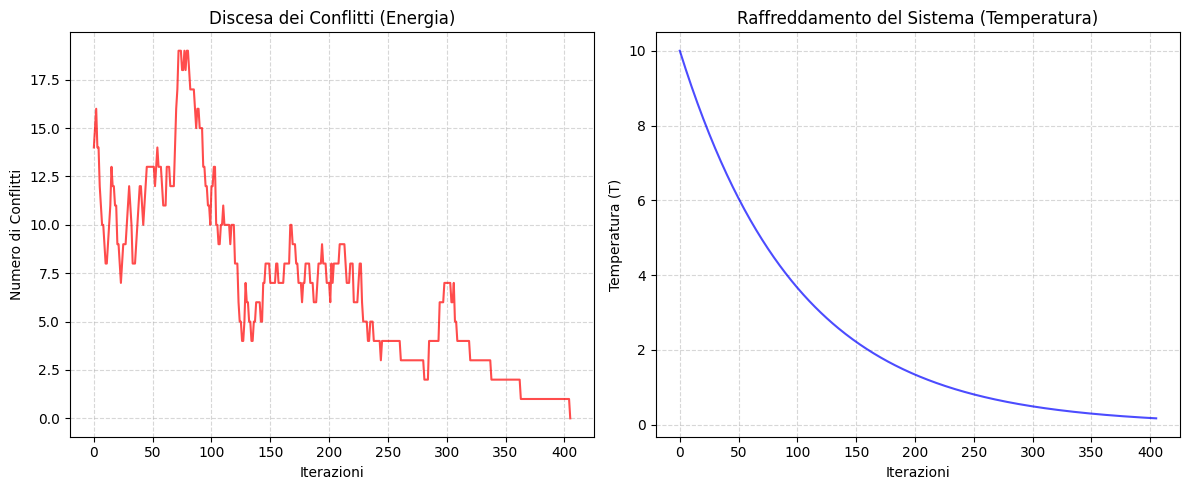

In [12]:
import pandas as pd
import random
import math
import matplotlib.pyplot as plt
from collections import Counter

# =============================================================================
# MODELLAZIONE CSP - RICERCA LOCALE: SIMULATED ANNEALING
# Capitolo 3 (Pinto) - Fuga dai Minimi Locali tramite Termodinamica
# =============================================================================

print("=" * 85)
print(" 🧠 AI SOLVER: LOCAL SEARCH - SIMULATED ANNEALING")
print("=" * 85)

# ─────────────────────────────────────────────
# 1. CARICAMENTO DATI E STATO INIZIALE
# ─────────────────────────────────────────────
df = pd.read_csv("csp_mumbai_espanso.csv")

def determina_area(row):
    if row.get("Area_Urban") == 1.0: return "Urban"
    if row.get("Area_Metropolitian") == 1.0: return "Metropolitan"
    if row.get("Area_Semi-Urban") == 1.0: return "Semi-Urban"
    return "Unknown"

orders_dict = {}
for _, row in df[df["Record_Type"] == "ORDER"].iterrows():
    orders_dict[row["Order_ID"]] = {
        "Order_ID": row["Order_ID"],
        "Is_Home": row["Category_Home"] == 1.0,
        "Is_Electronics": row["Category_Electronics"] == 1.0,
        "Area": determina_area(row)
    }

agents = {}
for _, row in df[df["Record_Type"] == "AGENT"].iterrows():
    is_van = row["Vehicle_van"] == 1.0
    agents[row["Agent_ID"]] = {
        "Rating": row["Agent_Rating"],
        "Is_Van": is_van,
        "Max_Total": 5 if is_van else 2,
        "Max_Home": 3 if is_van else 1
    }

# Generiamo un'assegnazione casuale di partenza
random.seed(42)
current_assignment = {}
agent_ids = list(agents.keys())

for o_id in orders_dict.keys():
    current_assignment[o_id] = random.choice(agent_ids)

# ─────────────────────────────────────────────
# 2. FUNZIONE DI VALUTAZIONE (ENERGIA / CONFLITTI)
# ─────────────────────────────────────────────
def get_conflicts(assignment):
    total_violations = 0
    agent_loads = {a: [] for a in agents}
    for o_id, a_id in assignment.items():
        agent_loads[a_id].append(o_id)
        
    for a_id, o_list in agent_loads.items():
        a_data = agents[a_id]
        areas = [orders_dict[o]["Area"] for o in o_list]
        primary_area = Counter(areas).most_common(1)[0][0] if areas else None
        home_count = sum(1 for o in o_list if orders_dict[o]["Is_Home"])
        
        # Capacità totali
        if len(o_list) > a_data["Max_Total"]:
            total_violations += (len(o_list) - a_data["Max_Total"])
        if home_count > a_data["Max_Home"]:
            total_violations += (home_count - a_data["Max_Home"])
            
        # Analisi singolo pacco
        for o_id in o_list:
            o_data = orders_dict[o_id]
            if o_data["Area"] != primary_area:
                total_violations += 1
            if o_data["Is_Electronics"] and a_data["Rating"] <= 3.8:
                total_violations += 1
                
    return total_violations

# ─────────────────────────────────────────────
# 3. MOTORE SIMULATED ANNEALING
# ─────────────────────────────────────────────
T = 10.0                # Temperatura iniziale (Alta = molta esplorazione caotica)
cooling_rate = 0.99     # Tasso di raffreddamento (Più è vicino a 1, più è lento)
min_T = 0.001
max_iter = 10000

current_conflicts = get_conflicts(current_assignment)
print(f"[1] Stato Iniziale Casuale. Conflitti di partenza (Energia): {current_conflicts}")
print(f"[2] Avvio Simulated Annealing (T_0={T}, cooling={cooling_rate})...")

history = [] # Per tracciare la discesa per il grafico
iterations = 0

while T > min_T and iterations < max_iter:
    if current_conflicts == 0:
        break # Soluzione Perfetta Trovata!
        
    # Mossa: seleziona un ordine a caso e cambiagli agente
    order_to_move = random.choice(list(orders_dict.keys()))
    old_agent = current_assignment[order_to_move]
    
    new_agent = random.choice(agent_ids)
    while new_agent == old_agent:
        new_agent = random.choice(agent_ids)
        
    # Applica temporaneamente la mossa per valutarla
    current_assignment[order_to_move] = new_agent
    new_conflicts = get_conflicts(current_assignment)
    
    # Calcolo del Delta Energia
    delta_e = new_conflicts - current_conflicts
    
    # Logica di Accettazione Termodinamica
    if delta_e <= 0:
        # Miglioramento (o stabilità): Accetta Sempre
        current_conflicts = new_conflicts
    else:
        # Peggioramento: Accetta con probabilità P = e^(-DeltaE / T)
        prob_accept = math.exp(-delta_e / T)
        if random.random() < prob_accept:
            # Mossa "sbagliata" accettata per fuggire da minimi locali
            current_conflicts = new_conflicts
        else:
            # Mossa rifiutata: Rollback
            current_assignment[order_to_move] = old_agent
            
    # Salva le statistiche del passo e raffredda il sistema
    history.append((iterations, T, current_conflicts))
    T *= cooling_rate
    iterations += 1

# ─────────────────────────────────────────────
# 4. OUTPUT E REPORT FINALE
# ─────────────────────────────────────────────
print("\n" + "=" * 85)
if current_conflicts == 0:
    print(f" ✅ SOLUZIONE OTTIMA TROVATA in {iterations} iterazioni!")
else:
    print(f" ⚠️ MOTORE RAFFREDDATO. Sistema congelato a {current_conflicts} conflitti residui.")
print("=" * 85)

# Generazione Tabella Finale
res_list = []
for o_id, a_id in current_assignment.items():
    o_data = orders_dict[o_id]
    cat = "Standard"
    if o_data["Is_Home"]: cat = "Home (Pesante)"
    if o_data["Is_Electronics"]: cat = "Electronics"
    
    res_list.append({
        "Order_ID": o_id,
        "Agente": a_id,
        "Area": o_data["Area"],
        "Categoria": cat
    })

df_results = pd.DataFrame(res_list).sort_values(by=["Agente", "Categoria"])
print("\n📦 ASSEGNAZIONE FINALE ORDINI:")
print(df_results.to_string(index=False))

# --- GENERAZIONE GRAFICO DELLA DISCESA ---
# (Esegui questo codice in un Jupyter Notebook o in un ambiente con interfaccia grafica)
iters = [x[0] for x in history]
temps = [x[1] for x in history]
confs = [x[2] for x in history]

plt.figure(figsize=(12, 5))

# Grafico Conflitti
plt.subplot(1, 2, 1)
plt.plot(iters, confs, color='red', alpha=0.7)
plt.title("Discesa dei Conflitti (Energia)")
plt.xlabel("Iterazioni")
plt.ylabel("Numero di Conflitti")
plt.grid(True, linestyle='--', alpha=0.5)

# Grafico Temperatura
plt.subplot(1, 2, 2)
plt.plot(iters, temps, color='blue', alpha=0.7)
plt.title("Raffreddamento del Sistema (Temperatura)")
plt.xlabel("Iterazioni")
plt.ylabel("Temperatura (T)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# Scommentare la riga sotto se si desidera salvare o mostrare il grafico localmente
# plt.savefig("simulated_annealing_plot.png")
# plt.show()

## Iterative Best Improvment

In [10]:
import pandas as pd
import random
from collections import Counter

# =============================================================================
# MODELLAZIONE CSP - RICERCA LOCALE: ITERATIVE BEST IMPROVEMENT (MIN-CONFLICTS)
# Capitolo 3 (Pinto) - Riparazione iterativa di un'assegnazione completa
# =============================================================================

print("=" * 85)
print(" 🧠 AI SOLVER: LOCAL SEARCH - ITERATIVE BEST IMPROVEMENT")
print("=" * 85)

# ─────────────────────────────────────────────
# 1. CARICAMENTO DATI E STATO INIZIALE
# ─────────────────────────────────────────────
df = pd.read_csv("csp_mumbai_espanso.csv")

def determina_area(row):
    if row.get("Area_Urban") == 1.0: return "Urban"
    if row.get("Area_Metropolitian") == 1.0: return "Metropolitan"
    if row.get("Area_Semi-Urban") == 1.0: return "Semi-Urban"
    return "Unknown"

# Inizializziamo i dizionari per un accesso O(1) rapido durante le iterazioni
orders_dict = {}
for _, row in df[df["Record_Type"] == "ORDER"].iterrows():
    orders_dict[row["Order_ID"]] = {
        "Order_ID": row["Order_ID"],
        "Is_Home": row["Category_Home"] == 1.0,
        "Is_Electronics": row["Category_Electronics"] == 1.0,
        "Area": determina_area(row)
    }

agents = {}
for _, row in df[df["Record_Type"] == "AGENT"].iterrows():
    is_van = row["Vehicle_van"] == 1.0
    agents[row["Agent_ID"]] = {
        "Rating": row["Agent_Rating"],
        "Is_Van": is_van,
        "Max_Total": 5 if is_van else 2,
        "Max_Home": 3 if is_van else 1
    }

# Assegnazione Totale Casuale (Ignorando i vincoli in fase zero)
random.seed(42) # Per riproducibilità, rimuovibile
current_assignment = {}
agent_ids = list(agents.keys())

for o_id in orders_dict.keys():
    current_assignment[o_id] = random.choice(agent_ids)

# ─────────────────────────────────────────────
# 2. FUNZIONE DI VALUTAZIONE h(s)
# ─────────────────────────────────────────────
def get_conflicts(assignment):
    """
    Calcola il numero totale di conflitti (violazioni dei vincoli).
    Ritorna: (totale_violazioni, lista_ordini_in_conflitto)
    """
    total_violations = 0
    conflicting_orders = set()
    
    # Raggruppa i carichi per agente
    agent_loads = {a: [] for a in agents}
    for o_id, a_id in assignment.items():
        agent_loads[a_id].append(o_id)
        
    for a_id, o_list in agent_loads.items():
        a_data = agents[a_id]
        
        # A. Calcolo dell'Area Maggioritaria (Primary Area)
        areas = [orders_dict[o]["Area"] for o in o_list]
        primary_area = None
        if areas:
            primary_area = Counter(areas).most_common(1)[0][0]
            
        # B. Conteggio Pacchi Home
        home_count = sum(1 for o in o_list if orders_dict[o]["Is_Home"])
        
        # VINCOLO 1: Capacità Globale
        if len(o_list) > a_data["Max_Total"]:
            total_violations += (len(o_list) - a_data["Max_Total"])
            conflicting_orders.update(o_list) # Tutti i pacchi di questo agente sono 'sospetti'
            
        # VINCOLO 2: Capacità Pesanti
        if home_count > a_data["Max_Home"]:
            total_violations += (home_count - a_data["Max_Home"])
            conflicting_orders.update([o for o in o_list if orders_dict[o]["Is_Home"]])
            
        # Analisi del singolo ordine per Area e Competenze
        for o_id in o_list:
            o_data = orders_dict[o_id]
            
            # VINCOLO 3: Coerenza Area
            if o_data["Area"] != primary_area:
                total_violations += 1
                conflicting_orders.add(o_id)
                
            # VINCOLO 4: Competenza Electronics
            if o_data["Is_Electronics"] and a_data["Rating"] <= 3.8:
                total_violations += 1
                conflicting_orders.add(o_id)
                
    return total_violations, list(conflicting_orders)

# ─────────────────────────────────────────────
# 3. MOTORE ITERATIVO (BEST IMPROVEMENT)
# ─────────────────────────────────────────────
initial_conflicts, _ = get_conflicts(current_assignment)
print(f"[1] Stato Iniziale Generato. Conflitti di partenza: {initial_conflicts}")
print("[2] Avvio Iterative Best Improvement...")

iterations = 0
max_iterations = 2000

while iterations < max_iterations:
    current_conflicts, conf_orders = get_conflicts(current_assignment)
    
    # Condizione di Terminazione: Soluzione perfetta trovata
    if current_conflicts == 0:
        break
        
    # Seleziona CASUALMENTE una variabile (ordine) in conflitto
    order_to_move = random.choice(conf_orders)
    
    best_agents = []
    min_eval_conflicts = float('inf')
    original_agent = current_assignment[order_to_move]
    
    # Valuta tutti i possibili assegnamenti per QUESTA variabile
    for a_id in agents:
        current_assignment[order_to_move] = a_id
        eval_conflicts, _ = get_conflicts(current_assignment)
        
        if eval_conflicts < min_eval_conflicts:
            min_eval_conflicts = eval_conflicts
            best_agents = [a_id]
        elif eval_conflicts == min_eval_conflicts:
            best_agents.append(a_id)
            
    # Applica Best Improvement (in caso di parità, scegli a caso per evitare loop infiniti)
    chosen_agent = random.choice(best_agents)
    current_assignment[order_to_move] = chosen_agent
    
    iterations += 1

# ─────────────────────────────────────────────
# 4. OUTPUT E CONFRONTO
# ─────────────────────────────────────────────
final_conflicts, _ = get_conflicts(current_assignment)

print("\n" + "=" * 85)
if final_conflicts == 0:
    print(f" ✅ SOLUZIONE OTTIMA TROVATA in {iterations} iterazioni!")
else:
    print(f" ⚠️ MOTORE BLOCCATO. Raggiunte {iterations} iterazioni. Conflitti residui: {final_conflicts}")
print("=" * 85)

# Costruzione Tabella Finale
res_list = []
for o_id, a_id in current_assignment.items():
    o_data = orders_dict[o_id]
    cat = "Standard"
    if o_data["Is_Home"]: cat = "Home (Pesante)"
    if o_data["Is_Electronics"]: cat = "Electronics"
    
    res_list.append({
        "Order_ID": o_id,
        "Agente": a_id,
        "Area": o_data["Area"],
        "Categoria": cat
    })

df_results = pd.DataFrame(res_list).sort_values(by=["Agente", "Categoria"])
print("\n📦 ASSEGNAZIONE FINALE ORDINI:")
print(df_results.to_string(index=False))

 🧠 AI SOLVER: LOCAL SEARCH - ITERATIVE BEST IMPROVEMENT
[1] Stato Iniziale Generato. Conflitti di partenza: 13
[2] Avvio Iterative Best Improvement...

 ✅ SOLUZIONE OTTIMA TROVATA in 10 iterazioni!

📦 ASSEGNAZIONE FINALE ORDINI:
     Order_ID    Agente         Area      Categoria
dfpz659976784  Agente_1        Urban       Standard
uvxk945339489  Agente_1        Urban       Standard
xkkd346236625  Agente_1        Urban       Standard
ejhz762773579 Agente_10 Metropolitan       Standard
yzvk478108563 Agente_10 Metropolitan       Standard
toju684352781 Agente_11 Metropolitan    Electronics
lazk867331051 Agente_11 Metropolitan Home (Pesante)
gggb753628772 Agente_12 Metropolitan Home (Pesante)
dwkc167246434 Agente_12 Metropolitan       Standard
fvsn629817930  Agente_2 Metropolitan    Electronics
gief601407685  Agente_2 Metropolitan    Electronics
cube489940966  Agente_2 Metropolitan Home (Pesante)
hyai486047097  Agente_2 Metropolitan       Standard
adus125614870  Agente_3 Metropolitan    Ele